In [5]:
%pip install pandas matplotlib scikit-learn

  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
ratings = pd.read_csv("../data/ml-latest-small/ratings.csv")
movies  = pd.read_csv("../data/ml-latest-small/movies.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape :", movies.shape)
print("Total Users  :", ratings.userId.nunique())
print("Unique Movies:", ratings.movieId.nunique())

print("\nSample Ratings:")
display(ratings.head()) # 'display' looks nicer in Jupyter than 'print'

Ratings shape: (100836, 4)
Movies shape : (9742, 3)
Total Users  : 610
Unique Movies: 9724

Sample Ratings:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [8]:
n_users = ratings.userId.nunique()
n_movies = ratings.movieId.nunique()

# Calculate sparsity
sparsity = 1 - (len(ratings) / (n_users * n_movies))
print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9830


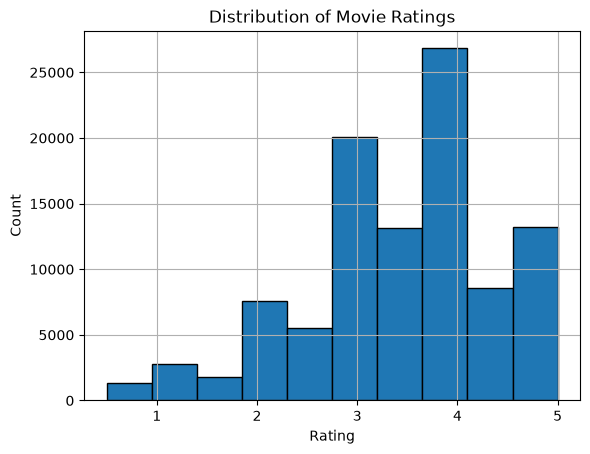

In [9]:
ratings['rating'].hist(bins=10, edgecolor='black')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [10]:
# Create a matrix where rows = users, columns = movies
# fillna(0) means if a user didn't rate a movie, we assume a rating of 0
user_movie_matrix = ratings.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
).fillna(0)

print("Matrix shape:", user_movie_matrix.shape)

Matrix shape: (610, 9724)


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose so rows are movies and columns are users
item_user_matrix = user_movie_matrix.T

# Calculate cosine similarity between all movies
# This creates a massive grid showing how similar every movie is to every other movie
item_similarity = cosine_similarity(item_user_matrix)

# Convert to a DataFrame for easy lookup
item_sim_df = pd.DataFrame(
    item_similarity, 
    index=item_user_matrix.index, 
    columns=item_user_matrix.index
)

print("Similarity matrix shape:", item_sim_df.shape)

Similarity matrix shape: (9724, 9724)


In [12]:
def recommend(movie_title, n=10):
    # 1. Find the movieId for the given title
    # We use .lower() to make the search case-insensitive
    match = movies[movies['title'].str.lower() == movie_title.lower()]
    
    if match.empty:
        return f"Movie '{movie_title}' not found. Try adding the year, e.g., 'Toy Story (1995)'"
    
    movie_id = match.iloc[0]['movieId']
    
    # 2. Get the similarity scores for this specific movie
    # Sort them from highest to lowest
    sim_scores = item_sim_df[movie_id].sort_values(ascending=False)
    
    # 3. Drop the movie itself (it is 100% similar to itself, which we don't want to recommend)
    sim_scores = sim_scores.drop(movie_id)
    
    # 4. Get the top N movie IDs
    top_movie_ids = sim_scores.head(n).index
    
    # 5. Map the IDs back to titles and genres
    recommendations = movies[movies['movieId'].isin(top_movie_ids)][['title', 'genres']]
    
    return recommendations

In [13]:
# Test with a very popular movie from the 90s
recommend("Toy Story (1995)")

,title,genres
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
314,Forrest Gump (1994),Comedy|Drama|Romance|War
322,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
418,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
546,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
615,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
911,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
964,Groundhog Day (1993),Comedy|Fantasy|Romance
969,Back to the Future (1985),Adventure|Comedy|Sci-Fi
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy


In [14]:
recommend("Matrix, The (1999)")

,title,genres
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
898,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
900,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure
911,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
1503,Saving Private Ryan (1998),Action|Drama|War
2078,"Sixth Sense, The (1999)",Drama|Horror|Mystery
2226,Fight Club (1999),Action|Crime|Drama|Thriller
2674,Gladiator (2000),Action|Adventure|Drama
3638,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
4800,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy


In [15]:
import pickle
import os

# Create the backend folder path just in case
os.makedirs("../backend", exist_ok=True)

# Save both the similarity matrix and the movies dataframe
with open("../backend/model.pkl", "wb") as f:
    pickle.dump({
        "item_sim": item_sim_df,
        "movies": movies
    }, f)

print("Model saved successfully to backend/model.pkl!")

Model saved successfully to backend/model.pkl!
